# 0. Orientation & Guardrails

*Establish scope, intent, and behavioral expectations so the lab stays focused on judgment, not tool-chasing.*


## 0.1 What This Session Is (and Is Not)

This session **is**:

- A guided walkthrough of a realistic enterprise AI workflow
- Focused on connecting models to data responsibly
- Designed to teach how to decide what to do next, not just how to run tools

This session is **not**:

- A fine-tuning workshop
- A deep dive into frameworks or internals
- A performance optimization exercise
- A "try every feature" demo

**Set expectations:**

- One scenario
- One execution path
- No fine-tuning today
- No optimization rabbit holes

> **Say explicitly:** "Today is about judgment, not heroics."


## 0.2 The Mental Model for Today

The governing principle for this lab:

> **Escalation of effort must be justified by evidence.**

Today's workflow follows this progression:

```
Baseline → Data Quality → Retrieval → Evaluation → Decision
```

Key ideas to land:

- We **start simple**
- We **measure outcomes**
- We **only escalate when the data tells us to**

> *"If you already know the answer is fine-tuning, you're skipping the part where most projects fail."*


## 0.3 What Success Looks Like Today

At the end of Day 2, participants should be able to:

- Explain **why ingestion quality matters more than model choice**
- Show **when RAG meaningfully improves outcomes**
- Evaluate whether results are *good enough* using simple criteria
- Articulate **why escalation is or is not justified**

Success is **not**:

- Running every cell successfully
- Memorizing commands
- Achieving "perfect" answers


## 0.4 How the Lab Will Run

Set these expectations **before** anyone opens a notebook.

- This lab is delivered as a **guided Jupyter notebook**
- Code and explanation are **interleaved**
- Participants are **not expected to write code from scratch**
- Pre-generated outputs exist for **every major step**

**Facilitator guidance:**

- If a cell takes more than ~2-3 minutes to run, **move on** (tolerance will vary by cell)
- Use pre-built outputs without apology
- Focus discussion on *interpretation*, not execution

---

## 0.5 Ground Rules

**One path forward** — We follow a single canonical workflow today.

**Questions are welcome; tangents are parked** — Interesting side topics are noted but deferred.

**No premature optimization** — We don't tune, scale, or optimize before we understand the problem.

**Evidence beats instinct** — "It feels better" is not a sufficient reason to escalate.


## 0.6 Setting the Tone

> "This lab reflects how successful AI engagements actually unfold: slowly at first, deliberately, and with far more attention paid to data and evaluation than to models."


## 0.7 Setting Up the Workbench
Before any code runs, the environment has to exist. This section walks through standing up your Red Hat AI workbench from scratch. This is not background infrastructure work. Every decision made here, storage size, image selection, repo structure, directly affects what is possible in the lab.

### 0.7.1 Log into the Lab

Using your Red Hat SSO credentials, log into the OpenShift AI dashboard at the URL provided by your instructor. Once authenticated, you will land on the Red Hat OpenShift AI home screen.

### 0.7.2 Create a Project

From the dashboard, navigate to Data Science Projects and click Create Project. Name the project `continuum-cluster`. This project is the namespace that will contain your workbench, storage, and all associated resources for the lab series.

Use the following images to guide you along.

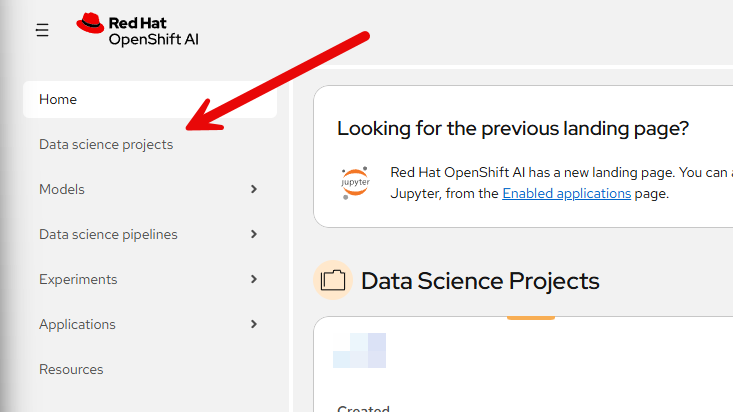

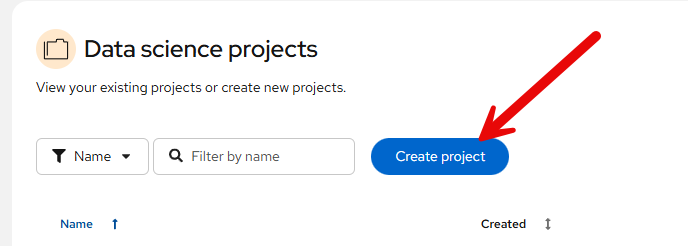

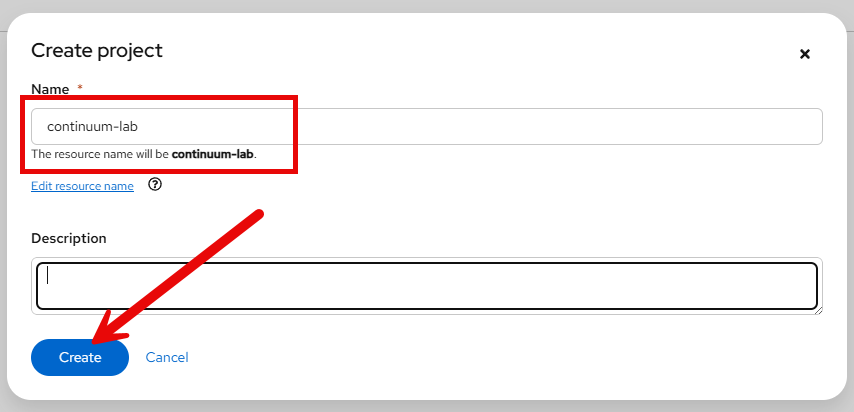



### 0.7.3 Create a Workbench
Inside your new project, click Create Workbench. 
Configure it as follows:

* Name: continuum-workbench
* Image: Jupyter | PyTorch | CUDA | Python 3.12
* Container size: Medium (6 CPU / 24 GiB)
* Accelerator: NVIDIA GPU L40S (1)


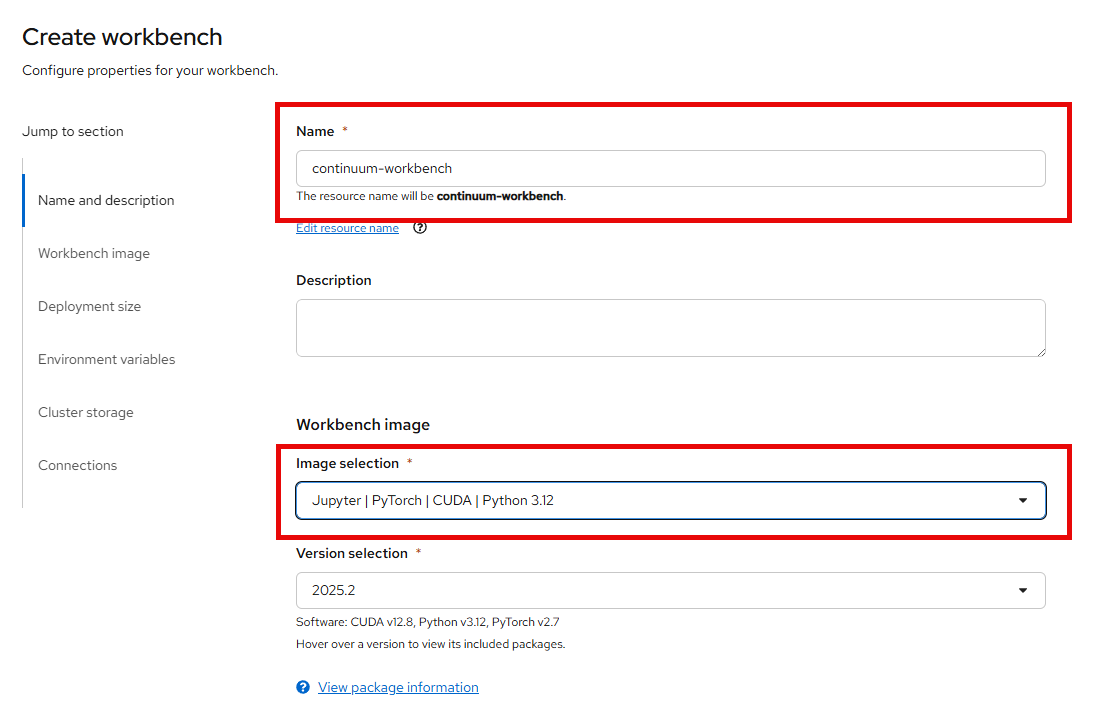

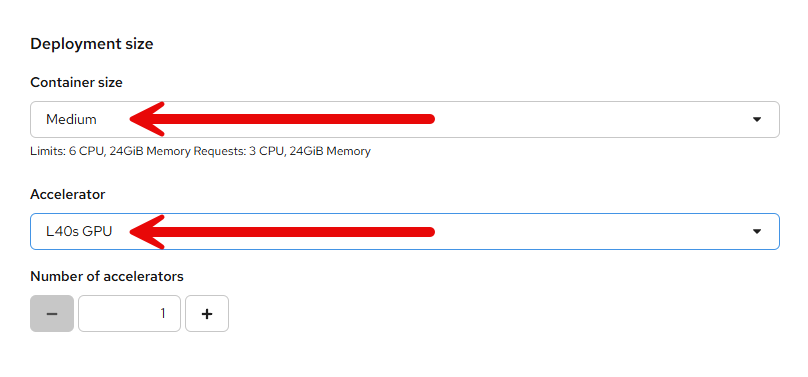

### 0.7.4 Increase Storage Size

The default storage allocation is not sufficient for this lab. The repo contains large model files tracked with Git LFS, and Docling generates substantial intermediate outputs. Before finalizing the workbench, increase the persistent storage to at least `50 GiB`.

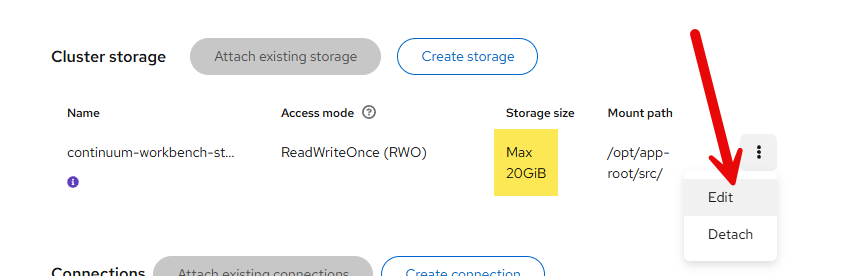

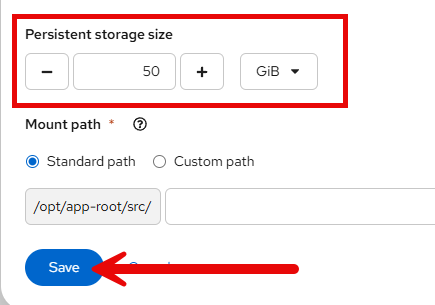



### 0.7.5 Launch Workbench When Ready
Click `Create Workbench`. The status will show as Starting. Wait until the status changes to Running, then click Open to launch JupyterLab in a new tab. This typically takes 1-3 minutes on first launch.


## 0.7.6 Open Terminal
Inside JupyterLab, open a terminal from the Launcher tab (File > New > Terminal). All remaining setup steps in this section are run here, not in a notebook cell.

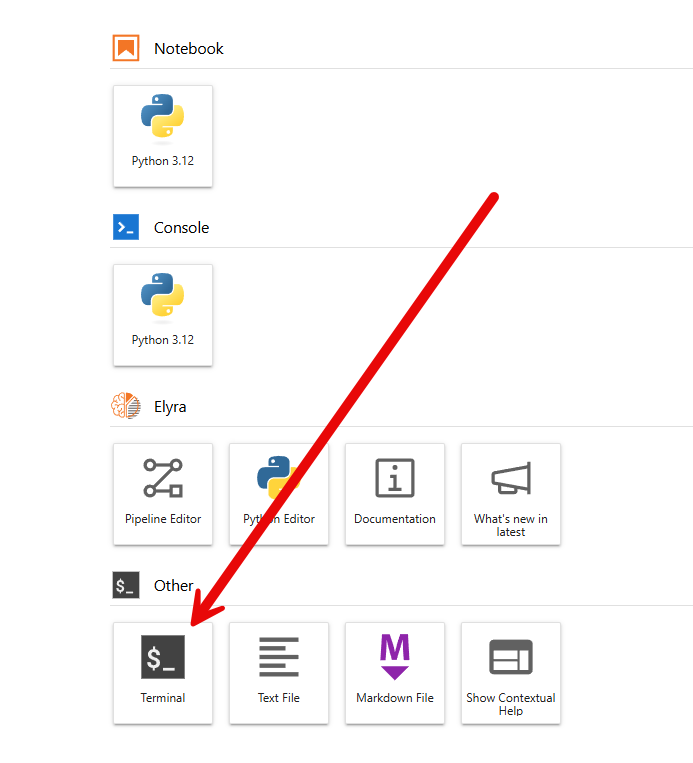


### 0.7.7 Install Git LFS
The lab repository uses Git LFS to store large files, including the source PDFs used for ingestion. Without LFS initialized, cloning the repo will pull pointer files instead of the actual content.

Run:

```
git lfs install
```

You should see: `Git LFS initialized.`

> **Note:** On some lab environments, `git lfs install` may fail with a "command not found" error. This is not a problem. If it fails, skip this step and continue to the next section. A fallback is provided to download the PDF files directly.


### 0.7.8 Pull Down Repo from GitHub

Clone the lab repository:

```
git clone https://github.com/FrankLaVigne/Q1ETX.git
```

After the clone completes, verify the PDFs pulled down correctly:

```
ls -lh Q1ETX/docs/*.pdf
```

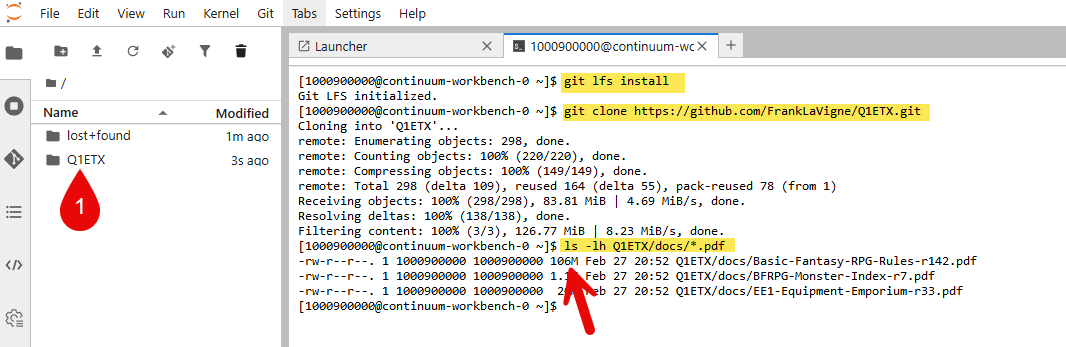

The main rulebook should be approximately 106 MB. If it shows a few hundred bytes instead, LFS did not pull the actual files. Use one of the following recovery options:

**Option A — If `git lfs` is available:**

```
cd Q1ETX && git lfs pull
```

**Option B — If `git lfs` is not available:**

Download the large PDF directly and then pull the remaining files from the repo:

```
cd Q1ETX/docs
curl -L -o Basic-Fantasy-RPG-Rules-r142.pdf http://franksworld.com/labs/redhat/Basic-Fantasy-RPG-Rules-r142.pdf
cd ..
```

Verify the downloads by checking file sizes again:

```
ls -lh docs/*.pdf
```

Once the file sizes look correct, the environment is ready. Move to Section 1.